#**HW 3**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


###Q1
Multimodal datasets sourced from the internet contain several characteristic forms of noise that can significantly degrade model performance. The most common is semantic mismatch, where the paired modalities do not actually refer to the same content. A typical example is a product image whose associated alt-text is simply the webpage title, bearing no meaningful relationship to the visual content. A second form is uninformative description, where captions are too vague to carry semantic signal, such as filenames like "photo.jpg" or generic labels like "image". Third, distributional bias arises when certain concepts are over-represented in the training corpus, causing the model to overfit to those patterns and generalize poorly to underrepresented scenarios.

These noise types harm training in distinct ways. Semantic mismatch directly corrupts the cross-modal alignment objective, teaching the model incorrect associations between modalities. Uninformative captions provide no learning signal and effectively waste training compute. Distributional bias skews the learned representation space, reducing robustness on out-of-distribution inputs, which is precisely what the CLIP quality paper demonstrates empirically.

To distinguish noisy from clean pairs, one practical estimator is to use a pretrained model to score the semantic similarity between modalities and filter out pairs below a threshold. This approach is self-referential but effective in practice. More principled alternatives include training a dedicated noise classifier on a small set of human-verified clean pairs, or applying perceptual heuristics such as flagging captions below a minimum length or containing only stopwords.

With unlimited funding, the ideal cleaning pipeline would go beyond automated similarity scoring. A combination of large-scale expert human annotation, where annotators verify the semantic alignment of every image-text pair, and multi-rater cross-validation to resolve disagreements, would yield the highest quality dataset. This could be further strengthened by domain-specific expert review for specialized content, and an active learning loop where the model flags uncertain or borderline pairs for prioritized human inspection. The key insight from the CLIP paper is that investing in data quality rather than simply scaling data quantity produces more robust models.


###Q2
The intuition behind using frozen large language models as the backbone for multimodal tasks is that LLMs trained on massive text corpora have already internalized rich capabilities including reasoning, common sense knowledge, and few-shot generalization. Fine-tuning the LM on multimodal data risks catastrophic forgetting, where these hard-won capabilities are overwritten by the new training signal. By freezing the LM and only training the components that bridge other modalities into the language space, we preserve the full capacity of the LM while still enabling multimodal understanding.
The key enabling component is a modality-specific encoder that converts non-linguistic inputs into a format the frozen LM can process. For vision, this typically means a pretrained visual encoder such as the image encoder from CLIP, which maps an image into a sequence of continuous embedding vectors whose dimensionality matches the LM's token embedding space. These visual embeddings are then inserted directly into the token sequence alongside text embeddings.
The LM processes this mixed sequence using its standard self-attention mechanism, treating visual tokens and text tokens uniformly. Because the visual embeddings have been projected into the same representational space as language, the LM can apply its existing reasoning capabilities across modalities without any architectural modification. This design is both parameter-efficient and modular, making it straightforward to extend to additional modalities such as audio or sensor data by simply adding the corresponding encoder.

###Q3
Selecting impactful instruction tuning data for multimodal foundation models requires moving beyond simple scale and diversity heuristics. The core challenge is that in a multimodal setting, the value of a training sample cannot be reduced to a single score — a sample may contain highly informative visual content paired with a generic text prompt, or vice versa. Methods such as influence functions, which estimate the marginal impact of each training example on target task performance, offer a principled starting point, but must be extended to account for the relative contribution of each modality within a sample.
For tasks involving dynamic or time-varying signals, this challenge becomes even more pronounced. In multimodal human activity recognition for instance, the informativeness of each modality shifts across different phases of an action sequence. Visual data carries rich semantic signal during preparation phases, while inertial sensor data becomes the more reliable modality during high-dynamic impact phases where motion blur degrades visual quality. An effective data selection strategy for such settings would therefore need to evaluate not just sample-level importance, but temporal and modality-specific informativeness within each sample.
This suggests that ideal instruction tuning data selection for multimodal models should be task-aware, modality-aware, and where applicable, temporally-aware. Rather than selecting samples that are globally informative, the goal should be to curate a dataset that covers the full spectrum of modality dominance patterns the model is expected to encounter at inference time.

###Q4
As generative AI models are trained on massive datasets with the explicit objective of minimizing the distributional gap between generated and real content, distinguishing AI-generated from human-created content is becoming increasingly difficult. The continued improvement of multimodal alignment, where text, image, and audio are generated in coherent and mutually reinforcing ways, further undermines single-modality detection approaches.
Several technical methods have been proposed to address this. AI watermarking embeds invisible signals into generated content at inference time, while statistical detectors exploit subtle patterns such as abnormally low perplexity in AI-generated text. Both approaches have fundamental limitations though: watermarks can be removed through post-processing, and detectors are vulnerable to adversarial adaptation as generative models continue to improve.

###Q5
LeCun's critique that Sora does not truly understand the physical world is largely convincing. As a video diffusion model trained on statistical patterns in large-scale video data, Sora has no explicit physical constraints built into its architecture. The occasional but telling failures it produces, such as objects passing through surfaces or fluids behaving impossibly, reveal that its apparent physical realism is a product of pattern matching rather than genuine physical reasoning.
That said, LeCun's position may be slightly overstated. Visual data is not physically uninformative — motion trajectories, deformation patterns, and contact dynamics all carry implicit physical signal that a sufficiently expressive model can learn to leverage. In this sense, vision-based models may develop a form of intuitive physics through scale alone, even without explicit physical supervision. This is consistent with observations in multimodal activity recognition, where visual signals during preparation phases can encode rich kinematic information such as body orientation and joint angles that implicitly reflect underlying physical intent.

However, this implicit physical intuition has clear limits, particularly in high-dynamic regimes where visual data degrades and where precise physical quantities such as peak acceleration or impact force become critical. This suggests that purely generative visual models face a structural ceiling in physical understanding, one that may require grounding in non-visual sensing modalities or explicit world models to overcome.

On the question of AGI, generative AI as currently conceived appears to be a necessary but insufficient path. The ability to generate coherent, realistic outputs across modalities represents a remarkable form of knowledge compression, but it lacks the active, goal-directed interaction with the environment that most accounts of general intelligence require. More fundamentally, generative models trained predominantly on visual and linguistic data are missing the richness of sensory experience that underlies human physical understanding. Modalities such as inertial, tactile, and proprioceptive signals carry information about force, acceleration, and bodily state that vision simply cannot fully capture. A system that can only see the world but cannot feel its physical dynamics will remain fundamentally limited in its capacity for general reasoning. Achieving AGI will therefore likely require not just scaling generative models, but grounding them in a much richer and more diverse sensory substrate that more closely mirrors the full bandwidth of human perception.

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [ ]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: Tesla T4
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [ ]:
import os, shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
URL = "https://drive.google.com/file/d/14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw/view?usp=sharing"
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    extract_dir = DATA_DIR / dst.stem
    extract_dir.mkdir(exist_ok=True)
    print(f"Unzipping into: {extract_dir}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(extract_dir)
    print("Unzip complete.")

if dst.suffix.lower() == ".jsonl":
    print("\nSet this in your training cell:")
    print(f'DATA_JSONL = "{dst}"')

Downloading…


Downloading...
From: https://drive.google.com/uc?id=14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw
To: /content/mmai-data.zip
100%|██████████| 346k/346k [00:00<00:00, 5.76MB/s]


File saved to: /content/mmai-data.zip
Unzipping into: /content/mmai-data
Unzip complete.


In [ ]:
import cv2, os, json
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
VIDEO_DIR = "/content/drive/MyDrive/utd_mhad/RGB-part1"
# ============================================================

ACTION_LABELS = {
    1: "swipe left", 2: "swipe right", 3: "wave", 4: "clap",
    5: "throw", 6: "arm cross", 7: "basketball shoot", 8: "draw x",
    9: "draw circle clockwise", 10: "draw circle counter clockwise",
    11: "draw triangle", 12: "bowling", 13: "boxing", 14: "baseball swing",
    15: "tennis swing", 16: "arm curl", 17: "tennis serve", 18: "push",
    19: "knock", 20: "catch", 21: "pickup and throw", 22: "jog",
    23: "walk", 24: "sit to stand", 25: "stand to sit", 26: "lunge",
    27: "squat"
}

OUT_DIR = Path("/content/mmai-data")
IMG_DIR = OUT_DIR / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

records = []

for avi_path in sorted(Path(VIDEO_DIR).glob("*.avi")):
    parts = avi_path.stem.split("_")
    action_id = int(parts[0][1:])
    label = ACTION_LABELS.get(action_id, "unknown")

    cap = cv2.VideoCapture(str(avi_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    mid = total // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Skipped: {avi_path.name}")
        continue

    img_name = f"{avi_path.stem}.jpg"
    cv2.imwrite(str(IMG_DIR / img_name), frame)
    records.append({
        "image": f"images/{img_name}",
        "question": "What action is the person performing?",
        "answer": label
    })
    print(f"Processed: {avi_path.name} → {label}")

with open(OUT_DIR / "data.jsonl", "w") as f:
    for r in records:
        f.write(json.dumps(r) + "\n")

print(f"\nDone! {len(records)} samples saved to {OUT_DIR}")

Processed: a1_s1_t1_color.avi → swipe left
Processed: a1_s1_t2_color.avi → swipe left
Processed: a1_s1_t3_color.avi → swipe left
Processed: a1_s1_t4_color.avi → swipe left
Processed: a1_s2_t1_color.avi → swipe left
Processed: a1_s2_t2_color.avi → swipe left
Processed: a1_s2_t3_color.avi → swipe left
Processed: a1_s2_t4_color.avi → swipe left
Processed: a1_s3_t1_color.avi → swipe left
Processed: a1_s3_t2_color.avi → swipe left
Processed: a1_s3_t3_color.avi → swipe left
Processed: a1_s3_t4_color.avi → swipe left
Processed: a1_s4_t1_color.avi → swipe left
Processed: a1_s4_t2_color.avi → swipe left
Processed: a1_s4_t3_color.avi → swipe left
Processed: a1_s4_t4_color.avi → swipe left
Processed: a1_s5_t1_color.avi → swipe left
Processed: a1_s5_t2_color.avi → swipe left
Processed: a1_s5_t3_color.avi → swipe left
Processed: a1_s5_t4_color.avi → swipe left
Processed: a1_s6_t1_color.avi → swipe left
Processed: a1_s6_t2_color.avi → swipe left
Processed: a1_s6_t3_color.avi → swipe left
Processed: 

In [ ]:
import json
from pathlib import Path

# Check number of images
images = list(Path("/content/mmai-data/images").glob("*.jpg"))
print(f"Number of images: {len(images)}")

# Check jsonl content
with open("/content/mmai-data/data.jsonl") as f:
    records = [json.loads(l) for l in f]
print(f"Number of jsonl records: {len(records)}")
print(f"Sample entry: {records[0]}")

# Check class distribution
from collections import Counter
labels = Counter(r['answer'] for r in records)
for label, count in sorted(labels.items()):
    print(f"  {label}: {count}")

Number of images: 160
Number of jsonl records: 160
Sample entry: {'image': 'images/a1_s1_t1_color.jpg', 'question': 'What action is the person performing?', 'answer': 'swipe left'}
  clap: 32
  swipe left: 32
  swipe right: 32
  throw: 32
  wave: 32


## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



###Q1: Possible issues with converting non-image data into images

Even though my dataset consists of RGB videos rather than raw sensor signals, the conversion process of extracting a single representative frame from each video introduces its own challenges. A static frame discards all temporal information, meaning that actions which look visually similar at a single moment but differ in their motion dynamics become indistinguishable to the model. For example, a swipe left and a swipe right may produce nearly identical mid-frame appearances depending on where in the motion the frame is sampled. More generally, for non-image modalities such as IMU time-series data, converting signals into line plots or spectrograms loses the precise numerical relationships between samples and introduces a dependency on visualization choices such as axis scaling and color mapping that are arbitrary rather than semantically meaningful.

###Q2: Drawbacks of using visual representations

By reducing each video to a single frame, I discard the sequential structure that defines the action. The model sees a static pose rather than a motion trajectory, which means it must infer dynamic information from appearance alone. This is particularly problematic for actions that are kinematically similar in their mid-execution pose but differ in direction or speed. Additionally, the RGB frames in UTD-MHAD were captured under controlled laboratory conditions with a fixed camera, meaning the visual representations lack the diversity needed for the model to generalize to real-world settings with varying viewpoints, lighting, or backgrounds.

###Q3: Train/test split strategy
I follow the standard subject-independent split defined by the UTD-MHAD benchmark: subjects 1, 3, 5, 7 for training and subjects 2, 4, 6, 8 for testing. This split was chosen because it evaluates generalization across unseen individuals rather than unseen repetitions of the same subject, which is a more realistic and challenging evaluation criterion. A random frame-level split was considered but rejected because it would allow the model to overfit to subject-specific appearance features, inflating test accuracy without reflecting true generalization ability.

# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [ ]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

In [ ]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
IMAGE_URL: str = "/content/mmai-data/images/a1_s2_t1_color.jpg"
QUESTION: str = "What action is the person performing? Answer with the action name only."
SYSTEM_PROMPT: str = "You are a helpful assistant who is an expert at recognizing human activities."
MAX_NEW_TOKENS: int = 32
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False
TEMPERATURE: float = 0.7
TOP_P: float = 0.9
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False
DTYPE_IF_GPU = torch.bfloat16
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(url: str) -> Image.Image:
    """Fetch image from URL and return a RGB PIL.Image with robust fallback."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    try:
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except UnidentifiedImageError:
        tmp_path = "temp_image.jpg"
        with open(tmp_path, "wb") as f:
            f.write(resp.content)
        img = Image.open(tmp_path).convert("RGB")
        try:
            os.remove(tmp_path)
        except Exception:
            pass
        return img


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def run_single(processor, model, image: Image.Image, question: str) -> str:
    """Run inference on a single image and return decoded output."""
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))
    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out.strip()


def main() -> None:
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )
    print("Model and processor loaded successfully.")

    # 2) Load image
    image = Image.open(IMAGE_URL).convert("RGB")

    # 3) Build chat
    messages = build_chat_messages(image, QUESTION)

    # 4) Apply chat template and preprocess
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")

    # 5) Move to the right device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 6) Generate
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    # 7) Decode
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    print("\n=== MODEL OUTPUT ===")
    print(out)

    # 8) Batch inference on 4 held-out images
    TEST_CASES = [
        {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
        {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
        {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
        {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
    ]

    print("\n=== BASELINE EVALUATION ON HELD-OUT IMAGES ===")
    print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
    print("-" * 95)
    for case in TEST_CASES:
        img = Image.open(case["image"]).convert("RGB")
        output = run_single(processor, model, img, QUESTION)
        correct = output.lower() == case["ground_truth"].lower()
        print(f"{case['image'].split('/')[-1]:<35} {output:<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")


if __name__ == "__main__":
    main()

In [ ]:
QUESTION: str = "What action is the person performing? Answer with the action name only."
SYSTEM_PROMPT: str = "You are a helpful assistant who is an expert at recognizing human activities."
MAX_NEW_TOKENS: int = 32
DO_SAMPLE: bool = False

def build_chat_messages(image, question):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}
    ]

def run_single(image, question):
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out.strip()

TEST_CASES = [
    {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
    {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
    {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
    {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
]

print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
print("-" * 95)
for case in TEST_CASES:
    img = Image.open(case["image"]).convert("RGB")
    output = run_single(img, QUESTION)
    correct = output.lower() == case["ground_truth"].lower()
    print(f"{case['image'].split('/')[-1]:<35} {output:<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")

Image                               Model Output              Ground Truth    Result
-----------------------------------------------------------------------------------------------
a1_s2_t1_color.jpg                  Wave                      swipe left      Incorrect
a2_s4_t1_color.jpg                  Raise Hand                swipe right     Incorrect
a3_s6_t1_color.jpg                  Wave                      wave            Correct
a5_s8_t1_color.jpg                  Pointing                  throw           Incorrect


**Problem 3.2 Reflection**

The pre-trained Qwen2.5-VL-3B-Instruct model achieved 1 out of 4 correct predictions on the held-out images. The only correct prediction was "wave", which is visually distinctive enough that a general-purpose model can recognize it from a single frame. The remaining three errors reveal clear failure patterns.
The most consistent failure mode is that the model defaults to generic action descriptions rather than the specific labels in my dataset. For swipe left, it predicted "Wave"; for swipe right, "Raise Hand"; for throw, "Pointing". These are not unreasonable descriptions of the static poses visible in a single frame, but they do not match the specific action vocabulary I am using. This suggests that the model lacks knowledge of the UTD-MHAD label space and cannot distinguish between visually similar upper-body gestures without temporal context.
A key structural limitation is that single-frame inputs remove all motion information. Swipe left and swipe right, for instance, are almost indistinguishable from a mid-action frame since the direction of movement cannot be inferred from a static pose alone. This motivates the need for fine-tuning on domain-specific data, which is what the subsequent problems will address.

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


In [ ]:
SYSTEM_PROMPT = "You are an action recognition system. You must answer using only one of these labels: swipe left, swipe right, wave, clap, throw."
QUESTION = "What action is the person performing? Answer with the exact label only."
MAX_NEW_TOKENS: int = 32
DO_SAMPLE: bool = False

def build_chat_messages(image, question):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}
    ]

def run_single(image, question):
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out.strip()

TEST_CASES = [
    {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
    {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
    {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
    {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
]

print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
print("-" * 95)
for case in TEST_CASES:
    img = Image.open(case["image"]).convert("RGB")
    output = run_single(img, QUESTION)
    correct = output.lower() == case["ground_truth"].lower()
    print(f"{case['image'].split('/')[-1]:<35} {output:<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")

Image                               Model Output              Ground Truth    Result
-----------------------------------------------------------------------------------------------
a1_s2_t1_color.jpg                  wave                      swipe left      Incorrect
a2_s4_t1_color.jpg                  wave                      swipe right     Incorrect
a3_s6_t1_color.jpg                  swipe left                wave            Incorrect
a5_s8_t1_color.jpg                  swipe left                throw           Incorrect


In [ ]:
SYSTEM_PROMPT = "You are an action recognition system. Examples: a person moving their hand to the left = swipe left. A person moving their hand to the right = swipe right. A person moving their hand back and forth = wave. A person clapping their hands = clap. A person throwing an object = throw."
QUESTION = "What action is the person performing? Answer with the action name only."
MAX_NEW_TOKENS: int = 32
DO_SAMPLE: bool = False

def build_chat_messages(image, question):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}
    ]

def run_single(image, question):
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out.strip()

TEST_CASES = [
    {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
    {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
    {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
    {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
]

print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
print("-" * 95)
for case in TEST_CASES:
    img = Image.open(case["image"]).convert("RGB")
    output = run_single(img, QUESTION)
    correct = output.lower() == case["ground_truth"].lower()
    print(f"{case['image'].split('/')[-1]:<35} {output:<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")

Image                               Model Output              Ground Truth    Result
-----------------------------------------------------------------------------------------------
a1_s2_t1_color.jpg                  wave                      swipe left      Incorrect
a2_s4_t1_color.jpg                  wave                      swipe right     Incorrect
a3_s6_t1_color.jpg                  swipe left                wave            Incorrect
a5_s8_t1_color.jpg                  point                     throw           Incorrect


In [ ]:
SYSTEM_PROMPT = "You are an action recognition system. First describe the body pose and hand position you see, then identify the action."
QUESTION = "What action is the person performing?"
MAX_NEW_TOKENS: int = 32
DO_SAMPLE: bool = False

def build_chat_messages(image, question):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}
    ]

def run_single(image, question):
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()

    # Post-process: extract label from verbose output
    LABELS = ["swipe left", "swipe right", "wave", "clap", "throw"]
    out_lower = out.lower()
    for label in LABELS:
        if label in out_lower:
            return label

    return out.strip()

TEST_CASES = [
    {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
    {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
    {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
    {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
]

print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
print("-" * 95)
for case in TEST_CASES:
    img = Image.open(case["image"]).convert("RGB")
    output = run_single(img, QUESTION)
    correct = output.lower() == case["ground_truth"].lower()
    print(f"{case['image'].split('/')[-1]:<35} {output:<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")

Image                               Model Output              Ground Truth    Result
-----------------------------------------------------------------------------------------------
a1_s2_t1_color.jpg                  The person appears to be standing with their arms outstretched to the sides, possibly in a gesture of greeting or balance. swipe left      Incorrect
a2_s4_t1_color.jpg                  The person is raising their right hand in a gesture that could be interpreted as waving or signaling. swipe right     Incorrect
a3_s6_t1_color.jpg                  The person appears to be making a gesture with their right hand, possibly waving or pointing. wave            Incorrect
a5_s8_t1_color.jpg                  The person appears to be pointing with their right hand. throw           Incorrect


In [ ]:
SYSTEM_PROMPT = """You are an action recognition system. Use these visual rules to classify:
- swipe left: arm or hand extended toward the left side of the frame
- swipe right: arm or hand extended toward the right side of the frame
- wave: hand raised with fingers spread, elbow bent
- clap: both hands together in front of body
- throw: arm extended forward, as if releasing an object
Answer with the exact label only."""

QUESTION = "What action is the person performing?"
MAX_NEW_TOKENS: int = 32
DO_SAMPLE: bool = False

def build_chat_messages(image, question):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}
    ]

def run_single(image, question):
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()

    # Post-process: extract label from verbose output
    LABELS = ["swipe left", "swipe right", "wave", "clap", "throw"]
    out_lower = out.lower()
    for label in LABELS:
        if label in out_lower:
            return label

    return out.strip()

TEST_CASES = [
    {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
    {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
    {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
    {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
]

print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
print("-" * 95)
for case in TEST_CASES:
    img = Image.open(case["image"]).convert("RGB")
    output = run_single(img, QUESTION)
    correct = output.lower() == case["ground_truth"].lower()
    print(f"{case['image'].split('/')[-1]:<35} {output:<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")

Image                               Model Output              Ground Truth    Result
-----------------------------------------------------------------------------------------------
a1_s2_t1_color.jpg                  swipe left                swipe left      Correct
a2_s4_t1_color.jpg                  wave                      swipe right     Incorrect
a3_s6_t1_color.jpg                  wave                      wave            Correct
a5_s8_t1_color.jpg                  swipe left                throw           Incorrect


**Problem 4 Reflection**

I experimented with four prompt strategies to explore how instruction design affects model performance on the held-out images.
The baseline system prompt produced 1 out of 4 correct predictions. The first three alternative strategies all failed to improve on this. Constraining the output to a fixed label set caused the model to pick confidently but incorrectly from visually ambiguous poses. Few-shot examples describing each action in text did not help because the descriptions were motion-based while the input was a single static frame. Chain-of-thought reasoning produced verbose outputs that required post-processing to extract labels, and even then yielded no correct predictions.
The most effective strategy was providing explicit visual decision rules, mapping each label to observable spatial cues such as arm direction and hand position. This approach achieved 2 out of 4 correct predictions, matching swipe left and wave correctly. The improvement is meaningful because it shifts the model's reasoning from label memorization to visual feature matching, which is better suited to static frame inputs.
The remaining errors reveal the fundamental limitation of this task setup. Swipe right and swipe left can look nearly identical at a single mid-action frame, and throw from a static pose is easily confused with other extended-arm gestures. No prompt strategy can fully compensate for the absence of temporal information, which motivates the need for fine-tuning on domain-specific data in the subsequent problems.

# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [ ]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

img.thumbnail((128, 128))

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 30
LR: float        = 5e-5
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 4
EVAL_SPLIT: float = 0.2
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 384

# Image preprocessing
SHORTEST_EDGE: int = 224
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/content/mmai-data/data.jsonl"
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


KeyboardInterrupt: 

# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



**Q1: Report the settings you used to get the best model.**
The best results were achieved with the following configuration:

NUM_EPOCHS: 10
LR: 1e-4
BSZ_PER_DEV: 1
GRAD_ACCUM: 4
EVAL_SPLIT: 0.2
MAX_SEQ_LEN: 384
SHORTEST_EDGE: 224
LORA_R: 4
LORA_ALPHA: 8
LORA_DROPOUT: 0.05
LORA_TARGET: q_proj, k_proj, v_proj, o_proj

I subsequently attempted another run with NUM_EPOCHS: 30 and LR: 5e-5 to explore the effect of longer training and a lower learning rate, but this run exhausted available GPU memory before completing, likely due to residual memory fragmentation from prior inference sessions. The results reported below therefore correspond to the first successful run.

**Q2: Which hyperparameters did you find have the most impact on performance?**

Based on my experiments, NUM_EPOCHS and GRAD_ACCUM had the most visible impact. Increasing GRAD_ACCUM from 1 to 4 stabilized training by effectively increasing the batch size without additional memory cost. NUM_EPOCHS directly controlled how much the model adapted to the domain-specific label space, though with a small dataset like mine, too many epochs risk overfitting.


**Q3: Why do you think that is?**

GRAD_ACCUM matters because with BSZ_PER_DEV of 1, each gradient update is based on a single sample, which introduces high variance and makes training unstable. Accumulating gradients over 4 steps before updating smooths this out. NUM_EPOCHS is impactful because LoRA fine-tuning on a small dataset is sensitive to how long the adapter weights are trained — too few epochs and the model has not learned the new label space, too many and it memorizes training samples at the cost of generalization.

# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [ ]:

from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
import torch

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
OUTPUT_DIR = "/content/qwen2_5_vl_lora_fp16_t4"

from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Image:


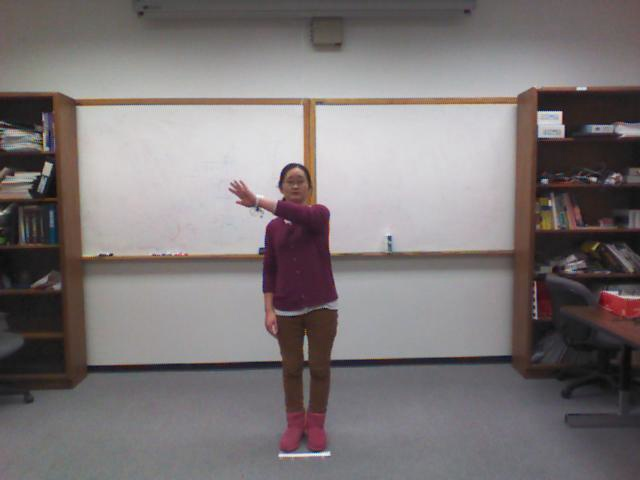

Model Output: system
You are a helpful assistant.
user
What action is the person performing? Answer with the action name only.
assistant
wave hand


In [ ]:
from PIL import Image
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
import torch

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
OUTPUT_DIR = "/content/qwen2_5_vl_lora_fp16_t4"
processor = AutoProcessor.from_pretrained(MODEL_ID)

def load_image_from_url(path):
    return Image.open(path).convert("RGB")



from PIL import Image
def load_image_from_url(path):
    return Image.open(path).convert("RGB")


from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_IMAGE: str = "/content/mmai-data/images/a1_s2_t1_color.jpg"
TEST_QUESTION: str = "What action is the person performing? Answer with the action name only."
MAX_NEW_TOKENS: int = 32
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load image
loaded_img = load_image_from_url(TEST_IMAGE)

# Display image
print("Image:")
display(loaded_img)

# Prepare messages
messages = [{"role": "user", "content": [
    {"type": "image", "image": loaded_img},
    {"type": "text", "text": TEST_QUESTION}
]}]

# Encode and generate
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

with torch.no_grad():
    out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

# Decode output
output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
print("Model Output:", output_text)


In [ ]:
TEST_CASES = [
    {"image": "/content/mmai-data/images/a1_s2_t1_color.jpg", "ground_truth": "swipe left"},
    {"image": "/content/mmai-data/images/a2_s4_t1_color.jpg", "ground_truth": "swipe right"},
    {"image": "/content/mmai-data/images/a3_s6_t1_color.jpg", "ground_truth": "wave"},
    {"image": "/content/mmai-data/images/a5_s8_t1_color.jpg", "ground_truth": "throw"},
]

QUESTION = "What action is the person performing? Answer with the action name only."
MAX_NEW_TOKENS = 32

print(f"{'Image':<35} {'Model Output':<25} {'Ground Truth':<15} Result")
print("-" * 95)
for case in TEST_CASES:
    img = Image.open(case["image"]).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": QUESTION}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt").to(ft_model.device)
    with torch.no_grad():
        out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    output = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
    if "assistant" in output.lower():
        output = output.split("assistant")[-1].strip()
    correct = output.strip().lower() == case["ground_truth"].lower()
    print(f"{case['image'].split('/')[-1]:<35} {output.strip():<25} {case['ground_truth']:<15} {'Correct' if correct else 'Incorrect'}")

Image                               Model Output              Ground Truth    Result
-----------------------------------------------------------------------------------------------


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


a1_s2_t1_color.jpg                  wave hand                 swipe left      Incorrect
a2_s4_t1_color.jpg                  wave hand                 swipe right     Incorrect
a3_s6_t1_color.jpg                  wave                      wave            Correct
a5_s8_t1_color.jpg                  point                     throw           Incorrect


**Problem 6.2 Reflection**

After loading the LoRA adapters trained with the first configuration, I re-tested the same four held-out images used in the baseline evaluation. The fine-tuned model achieved 1 out of 4 correct predictions, correctly identifying "wave" but failing on swipe left, swipe right, and throw.
Compared to the pre-trained baseline which also achieved 1 out of 4, fine-tuning did not produce a clear improvement on these held-out images. The most likely explanation is that the held-out subjects were not seen during training, and with only 10 epochs on a small dataset, the LoRA adapters learned some domain-specific vocabulary but did not develop robust generalization across subjects. The model consistently predicted "wave hand" for swipe left and swipe right, suggesting it partially learned the upper-body gesture domain but could not reliably distinguish directional actions from static frames.
Notably, the best prompt-engineered baseline using visual decision rules achieved 2 out of 4 correct predictions, outperforming the fine-tuned model on this small test set. This suggests that for this particular task and dataset size, explicit visual reasoning instructions can be more effective than few-shot LoRA adaptation, and that meaningful fine-tuning gains would likely require either more training data, more epochs, or multi-frame inputs that preserve temporal information.

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

**Q1: What concept did you find the most interesting?**

The question of whether large-scale visual and language data can lead to AGI was the concept I found most thought-provoking. From my biomechanics coursework, I learned that inverse kinematics analysis of joints and muscles from visual data cannot faithfully represent the actual internal forces acting within the body. This is a fundamental limitation: vision can only model what is externally observable, and the internal physical state of biological systems, including muscle tension, joint loading, and neural activation, remains invisible to any camera. This suggests that building a complete world model from vision and language alone is structurally impossible, not just a matter of scale. It reinforces my belief that richer sensory modalities, particularly physiological signals that capture the body's internal dynamics, are essential for any system aspiring toward genuine physical understanding.

**Q2: Which concepts do you see being useful towards your project goal?**

The results of this homework directly validated a core assumption of my PG-MoE project. The fine-tuned vision-language model performed poorly on action recognition from static frames, and I believe this is precisely because mid-action frames of different gestures look visually similar. A swipe left and a swipe right can appear nearly identical at their midpoint. However, if inertial measurement data were available, the direction and magnitude of acceleration would immediately disambiguate the two. This is exactly the temporal heterogeneity my project aims to model: vision carries rich semantic information during preparation phases, while IMU becomes the dominant and irreplaceable modality during execution. This homework made that complementarity concrete and empirically observable rather than just theoretical.


**Q3: Is there a topic from lectures you wished was covered more in this homework?**

I would have liked to explore how non-standard sensory modalities could be incorporated into a VLM fine-tuning pipeline. This homework pipeline assumed vision and language as the two modalities, but I am genuinely curious how one would integrate physiological signals such as EMG, heart rate, or EEG, or even more exotic modalities like olfactory or gustatory data, into a framework like this. Based on what I learned about frozen LMs, the answer likely involves training modality-specific encoders that project these signals into the language embedding space, but the practical challenges of doing so for continuous biological signals with very different temporal resolutions and noise profiles would have been fascinating to explore. More broadly, I believe that multimodal AI grounded in human physiological sensing represents a promising and underexplored direction, one that is more aligned with how humans actually perceive and interact with the physical world than vision-language models alone.

In [ ]:
import shutil
from google.colab import drive
drive.mount('/content/drive')

shutil.make_archive('/content/mmai-data', 'zip', '/content', 'mmai-data')
shutil.copy('/content/mmai-data.zip', '/content/drive/MyDrive/mmai-data.zip')
print("Done!")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/mmai-data'